# Pedroni Panel SVAR Analysis - DeFi Liquidations

This notebook runs Panel SVAR analysis on the relationship between:
- **Liquidation**: log-transformed USD value of collateral seized
- **Utilization**: Leverage ratio (borrowed/supplied)
- **Volatility**: Rolling std of collateral basket returns

Using Pedroni (2013) Panel SVAR methodology across 31 qualified DeFi protocols (T=592, start 2024-07-01).

In [1]:
import sys
from pathlib import Path

# Add pedroni_svar code to path
sys.path.insert(0, str(Path('../code/pedroni_svar')))

from SVAR import *
from panelSVAR import *
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")

print("Libraries loaded successfully")

Libraries loaded successfully


## 1. Load and Inspect Data

In [2]:
# Load panel data
panel = pd.read_parquet('../data/analysis/panel_svar_data_qualified.parquet')

print(f"Panel dimensions:")
print(f"  CSUs: {panel['csu'].nunique()}")
print(f"  Date range: {panel['date'].min()} to {panel['date'].max()}")
print(f"  Total observations: {len(panel):,}")
print()
print(f"Variable coverage:")
for col in ['liquidation', 'utilization', 'volatility']:
    coverage = panel[col].notna().mean() * 100
    print(f"  {col}: {coverage:.1f}%")

print(f"\nQualified CSUs ({panel['csu'].nunique()}):")
for csu in sorted(panel['csu'].unique()):
    print(f"  {csu}")

Panel dimensions:
  CSUs: 31
  Date range: 2024-07-01 to 2026-02-12
  Total observations: 18,352

Variable coverage:
  liquidation: 100.0%
  utilization: 90.9%
  volatility: 90.7%

Qualified CSUs (31):
  aave_v3_arbitrum
  aave_v3_avalanche
  aave_v3_base
  aave_v3_binance
  aave_v3_ethereum
  aave_v3_gnosis
  aave_v3_optimism
  aave_v3_polygon
  benqi_lending_avalanche
  compound_v2_ethereum
  compound_v3_arb_usdc
  compound_v3_arb_usdc_e
  compound_v3_arb_usdt
  compound_v3_arb_weth
  compound_v3_base_aero
  compound_v3_base_usdbc
  compound_v3_base_usdc
  compound_v3_base_weth
  compound_v3_eth_usdc
  compound_v3_eth_usds
  compound_v3_eth_usdt
  compound_v3_eth_weth
  fluid_lending_arbitrum
  fluid_lending_ethereum
  gearbox_ethereum
  lodestar_lending_arbitrum
  mendi_lending_linea
  moonwell_lending_base
  sonne_lending_optimism
  sparklend_ethereum
  venus_core_pool_binance


In [3]:
# Preview data
panel.head(10)

,date,csu,n_liquidations,total_collateral_usd,total_debt_usd,liquidation,utilization,volatility,basket_return
0,2024-07-01,aave_v3_arbitrum,3,122.313450,115.640516,4.814729,0.459038,0.013007,0.009691
1,2024-07-02,aave_v3_arbitrum,2,98.901707,91.217170,4.604187,0.463423,0.010955,-0.005447
2,2024-07-03,aave_v3_arbitrum,9,1848.640659,1750.247607,7.522747,0.464547,0.011389,-0.027323
3,2024-07-04,aave_v3_arbitrum,256,742118.219608,699973.102375,13.517265,0.462613,0.012255,-0.022081
4,2024-07-05,aave_v3_arbitrum,431,287062.910456,272635.910567,12.567460,0.468011,0.022875,-0.077528
5,2024-07-06,aave_v3_arbitrum,5,2838.454231,2594.138864,7.951367,0.464108,0.024340,0.021715
6,2024-07-07,aave_v3_arbitrum,23,32888.988678,31504.642961,10.400924,0.456978,0.024630,0.006819
7,2024-07-08,aave_v3_arbitrum,17,4100.746848,3907.248382,8.319168,0.461245,0.024768,-0.024327
8,2024-07-09,aave_v3_arbitrum,1,22.090447,21.139184,3.139419,0.460247,0.027478,0.036524
9,2024-07-10,aave_v3_arbitrum,1,5.967922,5.710645,1.941317,0.461852,0.027421,0.000639


## 2. Configure Panel SVAR

In [4]:
# Configuration
plot = True
savefig_path = "../data/analysis/svar_figures/"
excel_path = "../data/analysis/panel_svar_data_qualified.xlsx"
excel_sheet_name = "panel_data"

# Create required directories
Path("../output").mkdir(parents=True, exist_ok=True)
Path(savefig_path).mkdir(parents=True, exist_ok=True)

# Variables: [input_form, output_form]
# 0 = stationary, 1 = unit root
variables = {
    'utilization': [0, 0],  # Stationary (most exogenous)
    'liquidation': [0, 0],  # Stationary (middle)
    'volatility': [0, 0],   # Stationary (most endogenous)
}

# IMPORTANT: Order reflects causal structure
# Utilization → Liquidation → Volatility
variable_order = ['utilization', 'liquidation', 'volatility']
shocks = ['Utilization Shock', 'Liquidation Shock', 'Volatility Shock']

# Panel structure
td_col = ["date"]
member_col = "csu"

# Long-run restrictions (Cholesky ordering)
# Causal chain: Utilization causes Liquidation causes Volatility
lr_constraint = np.array([
    ['.', '0', '0'],  # Utilization: only utilization shock has long-run effect
    ['.', '.', '0'],  # Liquidation: utilization & liquidation shocks have effects
    ['.', '.', '.']   # Volatility: all shocks have long-run effects
])

# This means:
# - Utilization shock → affects utilization, liquidation, volatility (most exogenous)
# - Liquidation shock → affects liquidation, volatility (not utilization)
# - Volatility shock → affects volatility only (most endogenous)

# Sign restrictions (required: one per column)
lr_sign = np.array([
    ['+', '.', '.'],  # Utilization shock → positive utilization
    ['.', '+', '.'],  # Liquidation shock → positive liquidation
    ['.', '.', '+']   # Volatility shock → positive volatility
])

sr_constraint = np.array([])  # No short-run constraints

# Analysis parameters
maxlags = 7       # Test up to 7 lags
nsteps = 20       # 20-step impulse responses
lagmethod = 'aic' # Use AIC for lag selection

# Bootstrap
bootstrap = True
ndraws = 1000
signif = 0.05

print("="*70)
print("CONFIGURATION")
print("="*70)
print(f"\nCausal ordering: Utilization -> Liquidation -> Volatility")
print(f"Variables: {variable_order}")
print(f"Max lags: {maxlags}, Steps: {nsteps}")
print(f"Bootstrap: {bootstrap} ({ndraws} draws)")
print(f"\nLong-run constraints (Cholesky):")
print(lr_constraint)
print(f"\nSign restrictions:")
print(lr_sign)
print("="*70)

CONFIGURATION

Causal ordering: Utilization -> Liquidation -> Volatility
Variables: ['utilization', 'liquidation', 'volatility']
Max lags: 7, Steps: 20
Bootstrap: True (1000 draws)

Long-run constraints (Cholesky):
[['.' '0' '0']
 ['.' '.' '0']
 ['.' '.' '.']]

Sign restrictions:
[['+' '.' '.']
 ['.' '+' '.']
 ['.' '.' '+']]


## 3. Run Panel SVAR Analysis

In [5]:
# Create output directory
Path(savefig_path).mkdir(parents=True, exist_ok=True)

# Create input object
panel_input = VAR_input(
    variables=variables,
    variable_order=variable_order,
    shocks=shocks,
    td_col=td_col,
    member_col=member_col,
    M=None,
    sr_constraint=sr_constraint,
    lr_constraint=lr_constraint,
    lr_sign=lr_sign,  # FIXED: Changed from sr_sign to lr_sign
    maxlags=maxlags,
    nsteps=nsteps,
    lagmethod=lagmethod,
    bootstrap=bootstrap,
    ndraws=ndraws,
    signif=signif,
    excel_path=excel_path,
    excel_sheet_name=excel_sheet_name,
    df=pd.DataFrame(),
    plot=plot,
    savefig_path=savefig_path
)

print("Running Pedroni Panel SVAR...")
print("This may take several minutes (5-10 min for 1000 bootstrap draws)...\n")

# Run analysis
output = panelSVAR(panel_input)

print("\n" + "="*70)
print("✓ Analysis complete!")
print("="*70)
print(f"Results saved to: ../output/")
print(f"Figures will be generated in next cell")

Running Pedroni Panel SVAR...
This may take several minutes (5-10 min for 1000 bootstrap draws)...

Transformation matrix M:
[[ 6.58632260e-03  1.45468691e-03  2.22929075e-04]
 [-2.18378308e-01  8.25281785e-01  4.11165139e-01]
 [ 1.26963518e-04 -7.11975270e-04  2.19842848e-03]] 



/Users/lewisschrock/Desktop/Academics/thesis_v2.10/notebooks/../code/pedroni_svar/panelSVAR.py:115: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/notebooks/../code/pedroni_svar/panelSVAR.py:115: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/notebooks/../code/pedroni_svar/panelSVAR.py:115: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/notebooks/../code/pedroni_svar/panelSVAR.py:115: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Users/lewisschrock/Desktop/

/Users/lewisschrock/Desktop/Academics/thesis_v2.10/notebooks/../code/pedroni_svar/panelSVAR.py:115: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/notebooks/../code/pedroni_svar/panelSVAR.py:115: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/notebooks/../code/pedroni_svar/panelSVAR.py:115: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/notebooks/../code/pedroni_svar/panelSVAR.py:115: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))


/Users/lewisschrock/Desktop/Academics/thesis_v2.10/notebooks/../code/pedroni_svar/panelSVAR.py:115: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/notebooks/../code/pedroni_svar/panelSVAR.py:115: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/notebooks/../code/pedroni_svar/panelSVAR.py:115: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/notebooks/../code/pedroni_svar/panelSVAR.py:115: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))


SVAR failed for compound_v3_base_weth: 2-th leading minor of the array is not positive definite


/Users/lewisschrock/Desktop/Academics/thesis_v2.10/notebooks/../code/pedroni_svar/panelSVAR.py:115: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/notebooks/../code/pedroni_svar/panelSVAR.py:115: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/notebooks/../code/pedroni_svar/panelSVAR.py:115: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/notebooks/../code/pedroni_svar/panelSVAR.py:115: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Users/lewisschrock/Desktop/

SVAR failed for gearbox_ethereum: 1-th leading minor of the array is not positive definite
SVAR failed for sonne_lending_optimism: 2-th leading minor of the array is not positive definite


/Users/lewisschrock/Desktop/Academics/thesis_v2.10/notebooks/../code/pedroni_svar/panelSVAR.py:115: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/notebooks/../code/pedroni_svar/panelSVAR.py:115: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/notebooks/../code/pedroni_svar/panelSVAR.py:115: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/notebooks/../code/pedroni_svar/panelSVAR.py:115: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))



✓ Analysis complete!
Results saved to: ../output/
Figures will be generated in next cell


## 4. View Results

In [6]:
# Display impulse responses
if hasattr(output, 'ir'):
    print("Impulse Responses:")
    print(output.ir)

In [7]:
# List generated figures
import os

fig_dir = Path(savefig_path)
if fig_dir.exists():
    figures = list(fig_dir.glob('*.png')) + list(fig_dir.glob('*.pdf'))
    print(f"Generated {len(figures)} figures:")
    for fig in sorted(figures):
        print(f"  {fig.name}")
else:
    print("No figures directory found")

Generated 18 figures:
  common_shock_irfs.pdf
  common_shock_irfs.png
  composite_shock_irfs.pdf
  composite_shock_irfs.png
  heterogeneous_common_shock_irfs.pdf
  heterogeneous_common_shock_irfs.png
  heterogeneous_composite_shock_irfs.pdf
  heterogeneous_composite_shock_irfs.png
  heterogeneous_irfs_overlaid.pdf
  heterogeneous_irfs_overlaid.png
  heterogeneous_irfs_with_mean.pdf
  heterogeneous_irfs_with_mean.png
  individual_common_shock_irfs.pdf
  individual_common_shock_irfs.png
  irf_heatmaps.pdf
  irf_heatmaps.png
  lambda_loadings.pdf
  lambda_loadings.png


Saved IRF plots to ../data/analysis/svar_figures/


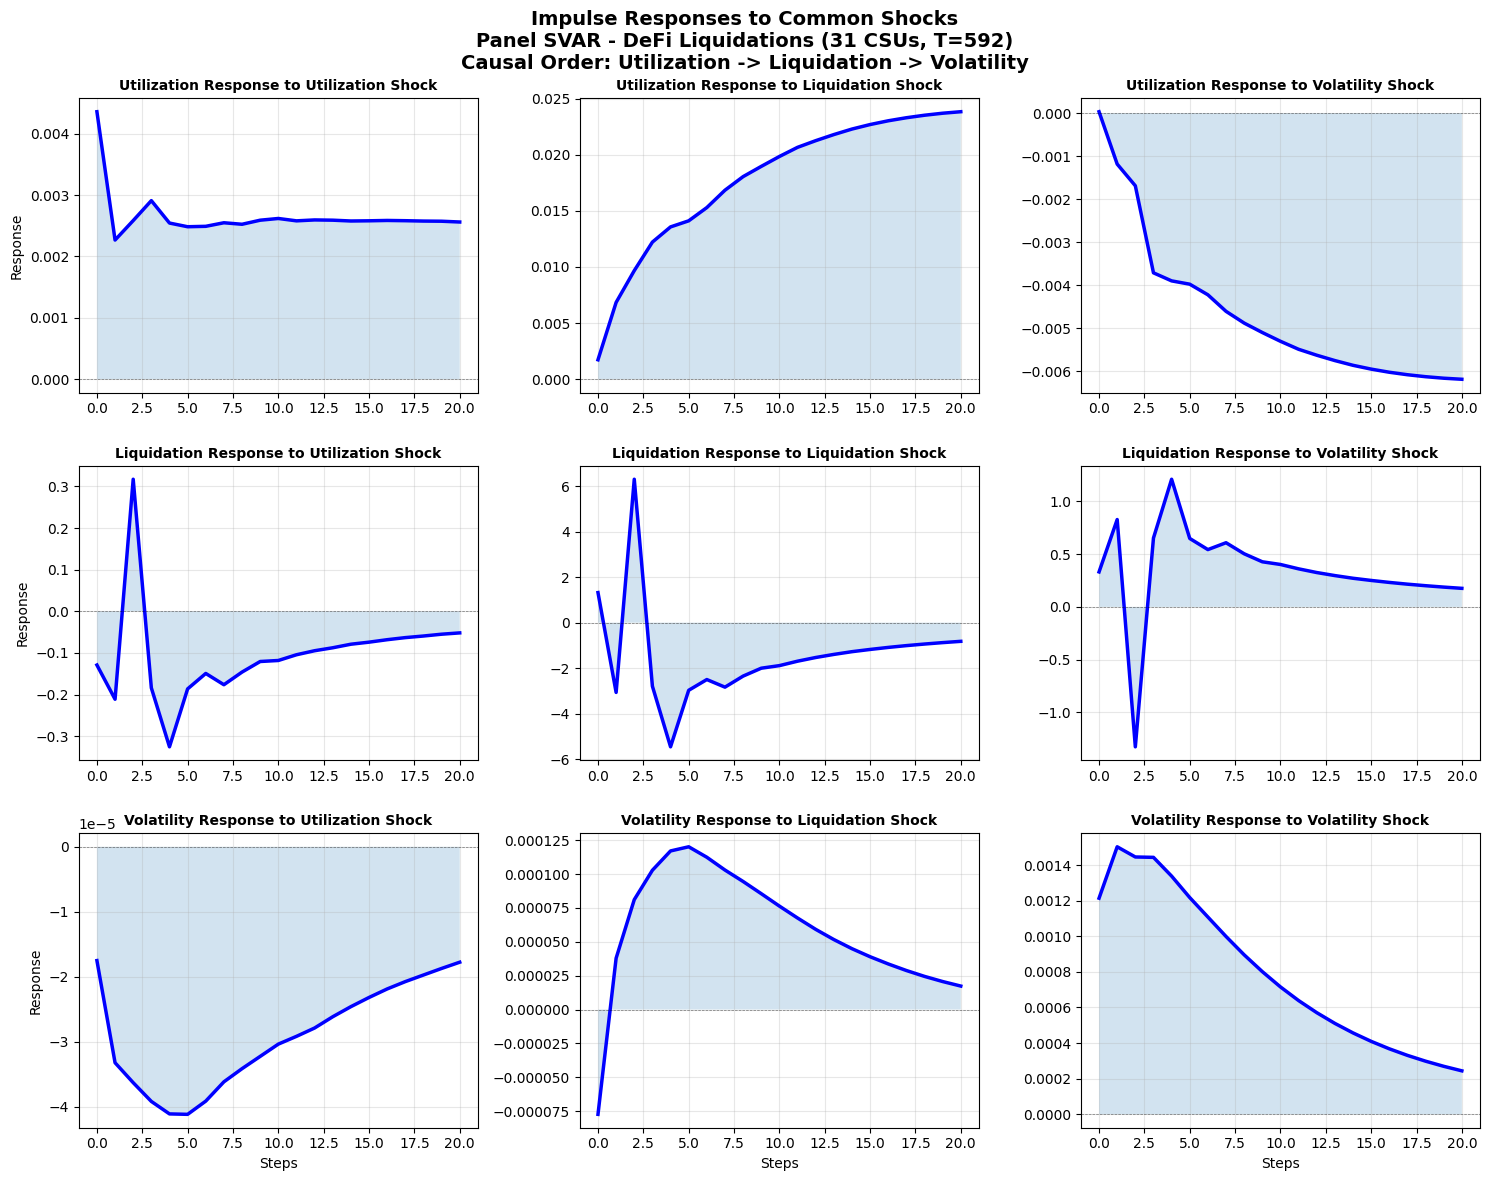

In [8]:
# Generate IRF plots from results
import matplotlib.pyplot as plt
import seaborn as sns

# Read common shock results
df_common = pd.read_excel('../output/ind-IRs-to-common-shocks.xlsx')

# Create 3x3 grid of IRF plots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Impulse Responses to Common Shocks\nPanel SVAR - DeFi Liquidations (31 CSUs, T=592)\nCausal Order: Utilization -> Liquidation -> Volatility',
             fontsize=14, fontweight='bold')

# Updated variable order to match causal structure
variables = ['utilization', 'liquidation', 'volatility']

for i in range(3):
    for j in range(3):
        ax = axes[i, j]
        
        # Get IRF data (columns are like IR11_0, IR11_1, ..., IR11_20 for var1->shock1)
        col_prefix = f'IR{i+1}{j+1}_'
        cols = [col for col in df_common.columns if col.startswith(col_prefix)]
        
        if cols:
            # Average across CSUs
            irf_data = df_common[cols].mean(axis=0).values
            steps = range(len(irf_data))
            
            # Plot
            ax.plot(steps, irf_data, 'b-', linewidth=2.5)
            ax.axhline(0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)
            ax.fill_between(steps, 0, irf_data, alpha=0.2)
            
            # Labels with clearer notation
            response_var = variables[i].capitalize()
            shock_var = variables[j].capitalize()
            ax.set_title(f"{response_var} Response to {shock_var} Shock", 
                        fontsize=10, fontweight='bold')
            if i == 2:
                ax.set_xlabel('Steps')
            if j == 0:
                ax.set_ylabel('Response')
            ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(savefig_path + 'common_shock_irfs.png', dpi=300, bbox_inches='tight')
plt.savefig(savefig_path + 'common_shock_irfs.pdf', bbox_inches='tight')
print("Saved IRF plots to", savefig_path)
plt.show()